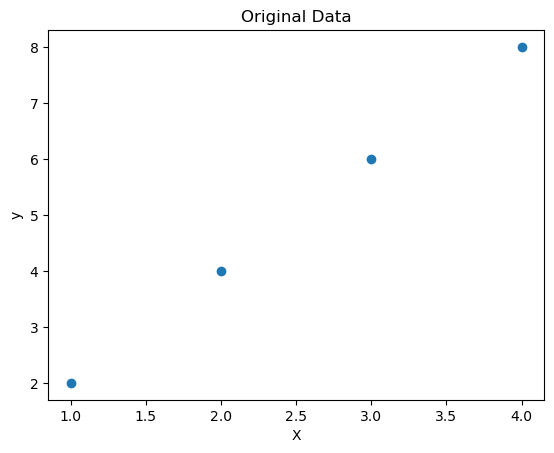

In [1]:
import torch
import matplotlib.pyplot as plt

# Sample dataset: 1 input feature, 1 output
X = torch.tensor([[1.0],[2.0],[3.0],[4.0]], dtype=torch.float32)
y = torch.tensor([[2.0],[4.0],[6.0],[8.0]], dtype=torch.float32)  # y = 2*x

# Plot original data
plt.scatter(X.numpy(), y.numpy())
plt.title("Original Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


2️⃣ Create a simple neuron

In [ ]:

# Initialize weight and bias randomly
weight = torch.randn(1, requires_grad=True)  # random starting weight
bias = torch.randn(1, requires_grad=True)    # random starting bias


3️⃣ Forward function (prediction)

In [3]:
def forward(x):
    return x * weight + bias


4️⃣ Loss functio

In [4]:
def mse(y_pred, y_true):
    return ((y_pred - y_true)**2).mean()


In [5]:
learning_rate = 0.01


6️⃣ Training loop

In [6]:
for epoch in range(50):
    y_pred = forward(X)
    loss = mse(y_pred, y)
    
    loss.backward()  # calculate gradients
    
    # update weights and bias
    with torch.no_grad():
        weight -= learning_rate * weight.grad
        bias -= learning_rate * bias.grad
    
    # zero gradients for next step
    weight.grad.zero_()
    bias.grad.zero_()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: weight={weight.item():.3f}, bias={bias.item():.3f}, loss={loss.item():.3f}")


Epoch 0: weight=0.139, bias=-1.571, loss=61.996
Epoch 10: weight=1.932, bias=-0.933, loss=1.713
Epoch 20: weight=2.214, bias=-0.811, loss=0.147
Epoch 30: weight=2.252, bias=-0.771, loss=0.100
Epoch 40: weight=2.252, bias=-0.746, loss=0.093


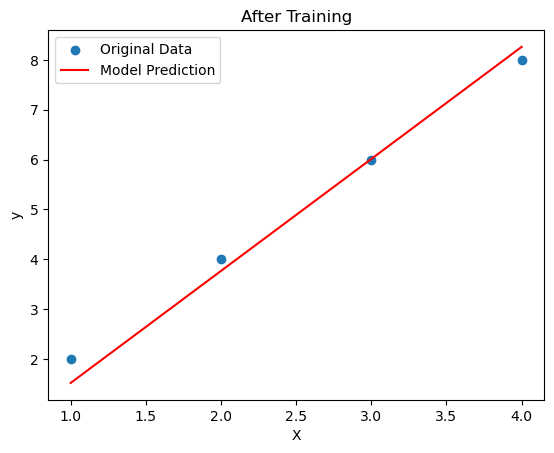

In [7]:
# Plot after training
y_pred = forward(X).detach()  # predictions after training
plt.scatter(X.numpy(), y.numpy(), label="Original Data")
plt.plot(X.numpy(), y_pred.numpy(), color='r', label="Model Prediction")
plt.title("After Training")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


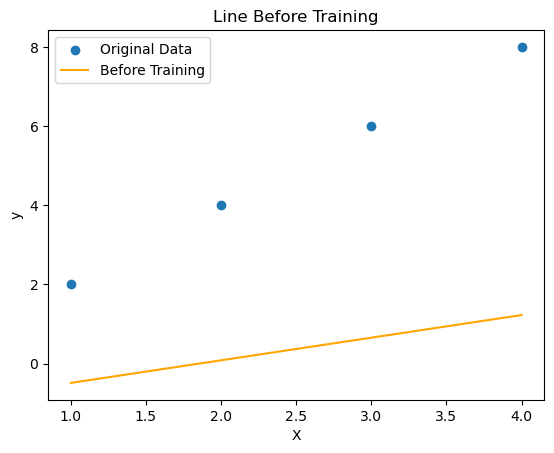

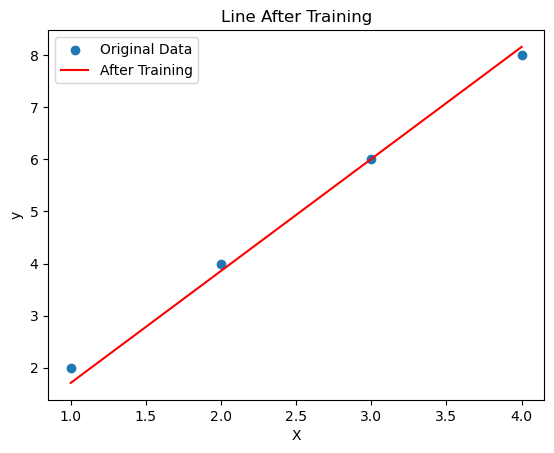

Trained weight: 2.150, bias: -0.442


In [8]:
import torch
import matplotlib.pyplot as plt

# Sample dataset: 1 input feature
X = torch.tensor([[1.0],[2.0],[3.0],[4.0]])
y = torch.tensor([[2.0],[4.0],[6.0],[8.0]])  # y = 2*x

# Initialize weight and bias randomly
weight = torch.randn(1, requires_grad=True)
bias = torch.randn(1, requires_grad=True)

# Forward function
def forward(x):
    return x * weight + bias

# Plot before training
y_pred_before = forward(X).detach()
plt.scatter(X.numpy(), y.numpy(), label="Original Data")
plt.plot(X.numpy(), y_pred_before.numpy(), color='orange', label="Before Training")
plt.title("Line Before Training")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Training loop
learning_rate = 0.01
for epoch in range(50):
    y_pred = forward(X)
    loss = ((y_pred - y)**2).mean()
    loss.backward()
    
    with torch.no_grad():
        weight -= learning_rate * weight.grad
        bias -= learning_rate * bias.grad
        weight.grad.zero_()
        bias.grad.zero_()

# Plot after training
y_pred_after = forward(X).detach()
plt.scatter(X.numpy(), y.numpy(), label="Original Data")
plt.plot(X.numpy(), y_pred_after.numpy(), color='red', label="After Training")
plt.title("Line After Training")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

print(f"Trained weight: {weight.item():.3f}, bias: {bias.item():.3f}")
